# FaceForge — Phase 0: Environment and Data Pipeline

**Goal:** Install dependencies, download CelebA, build the dataset class, visualize a batch, and compute attribute statistics.

Run all cells top-to-bottom. Each cell is self-contained and safe to re-run after session resume.

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
!pip install -q ftfy clip-anytorch scikit-image matplotlib

In [16]:
import os, subprocess, shutil, zipfile, sys
import torch, torchvision

# persistent data
DRIVE_ROOT   = '/content/drive/MyDrive/FaceForge'
CKPT_ROOT    = os.path.join(DRIVE_ROOT, 'checkpoints')
REPO_ROOT    = '/content/FaceForge'
DRIVE_DATA = '/content/drive/MyDrive/FaceForge/data/celeba'
LOCAL_DATA = '/content/celeba_local'
LOCAL_CELEBA = os.path.join(LOCAL_DATA, 'celeba')

if not os.path.exists(os.path.join(LOCAL_DATA, 'img_align_celeba')):
  os.makedirs(LOCAL_DATA, exist_ok=True)

  print('Copying zip from Drive to local SSD...')
  shutil.copy(os.path.join(DRIVE_DATA, 'img_align_celeba.zip'), '/content/img_align_celeba.zip')

  print('Extracting...')
  with zipfile.ZipFile('/content/img_align_celeba.zip', 'r') as z:
    z.extractall(LOCAL_DATA)
  os.remove('/content/img_align_celeba.zip')

  # Copy the small metadata files (attr, bbox, etc.)
  for f in ['list_attr_celeba.txt', 'identity_CelebA.txt',
            'list_bbox_celeba.txt', 'list_landmarks_align_celeba.txt',
            'list_eval_partition.txt']:
    src = os.path.join(DRIVE_DATA, f)
    if os.path.exists(src):
      shutil.copy(src, os.path.join(LOCAL_CELEBA, f))

  print(f'Done. Data ready at {LOCAL_DATA}')
else:
  print('Local data already ready.')

DATA_ROOT = LOCAL_DATA

os.makedirs(CKPT_ROOT, exist_ok=True)

print(f'Data root: {DATA_ROOT}')
print(f'Checkpoint root: {CKPT_ROOT}')
print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.version.cuda}')
print(f'GPU      : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"}')

Local data already ready.
Data root: /content/celeba_local
Checkpoint root: /content/drive/MyDrive/FaceForge/checkpoints
PyTorch  : 2.10.0+cu128
CUDA     : 12.8
GPU      : Tesla T4


In [17]:
REPO_URL = 'https://github.com/janampatel/FaceForge.git'

if os.path.isdir(REPO_ROOT):
    print('Repo exists — pulling latest...')
    subprocess.run(['git', '-C', REPO_ROOT, 'pull'], check=True)
else:
    print('Cloning repo...')
    subprocess.run(['git', 'clone', REPO_URL, REPO_ROOT], check=True)

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print('Repo ready at', REPO_ROOT)

Repo exists — pulling latest...
Repo ready at /content/FaceForge


## Download CelebA

**Primary path:** `torchvision.datasets.CelebA` with `download=True`.  
**Fallback:** If Google Drive throttles the download, follow the manual instructions printed below.

In [18]:
from data_pipeline import celeba_is_downloaded
import torchvision

if celeba_is_downloaded(DATA_ROOT):
    print('CelebA already downloaded — skipping.')
else:
    print('Attempting automatic download via torchvision...')
    print('This can fail with a Google Drive quota error. If it does, see fallback below.\n')
    torchvision.datasets.CelebA(
        root=DATA_ROOT,
        split='train',
        target_type='attr',
        download=True
    )

CelebA already downloaded — skipping.


## Build DataLoader and Verify Shapes

In [20]:
from data_pipeline import make_dataloader, SELECTED_ATTRS, NUM_ATTRS
import torch

train_loader = make_dataloader(
    root=DATA_ROOT,
    split='train',
    download=False,
    batch_size=64,
    num_workers=2
)

images, attrs = next(iter(train_loader))

print(f'Image batch : shape={images.shape}  dtype={images.dtype}  '
      f'min={images.min():.2f}  max={images.max():.2f}')
print(f'Attr  batch : shape={attrs.shape}   dtype={attrs.dtype}')
print(f'Selected attributes ({NUM_ATTRS}): {SELECTED_ATTRS}')

# Hard assertions — these must pass before proceeding
assert images.shape == (64, 3, 64, 64), f'Bad image shape: {images.shape}'
assert attrs.shape  == (64, 18),        f'Bad attr shape: {attrs.shape}'
assert attrs.dtype  == torch.float32,   f'Attrs should be float32, got {attrs.dtype}'
assert images.min() >= -1.01 and images.max() <= 1.01, 'Images not in [-1, 1]'

Image batch : shape=torch.Size([64, 3, 64, 64])  dtype=torch.float32  min=-1.00  max=1.00
Attr  batch : shape=torch.Size([64, 18])   dtype=torch.float32
Selected attributes (18): ['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Black_Hair', 'Blond_Hair', 'Brown_Hair', 'Bushy_Eyebrows', 'Eyeglasses', 'Male', 'Mouth_Slightly_Open', 'Mustache', 'No_Beard', 'Pale_Skin', 'Smiling', 'Young']


## Visualize a 4×4 Image Grid

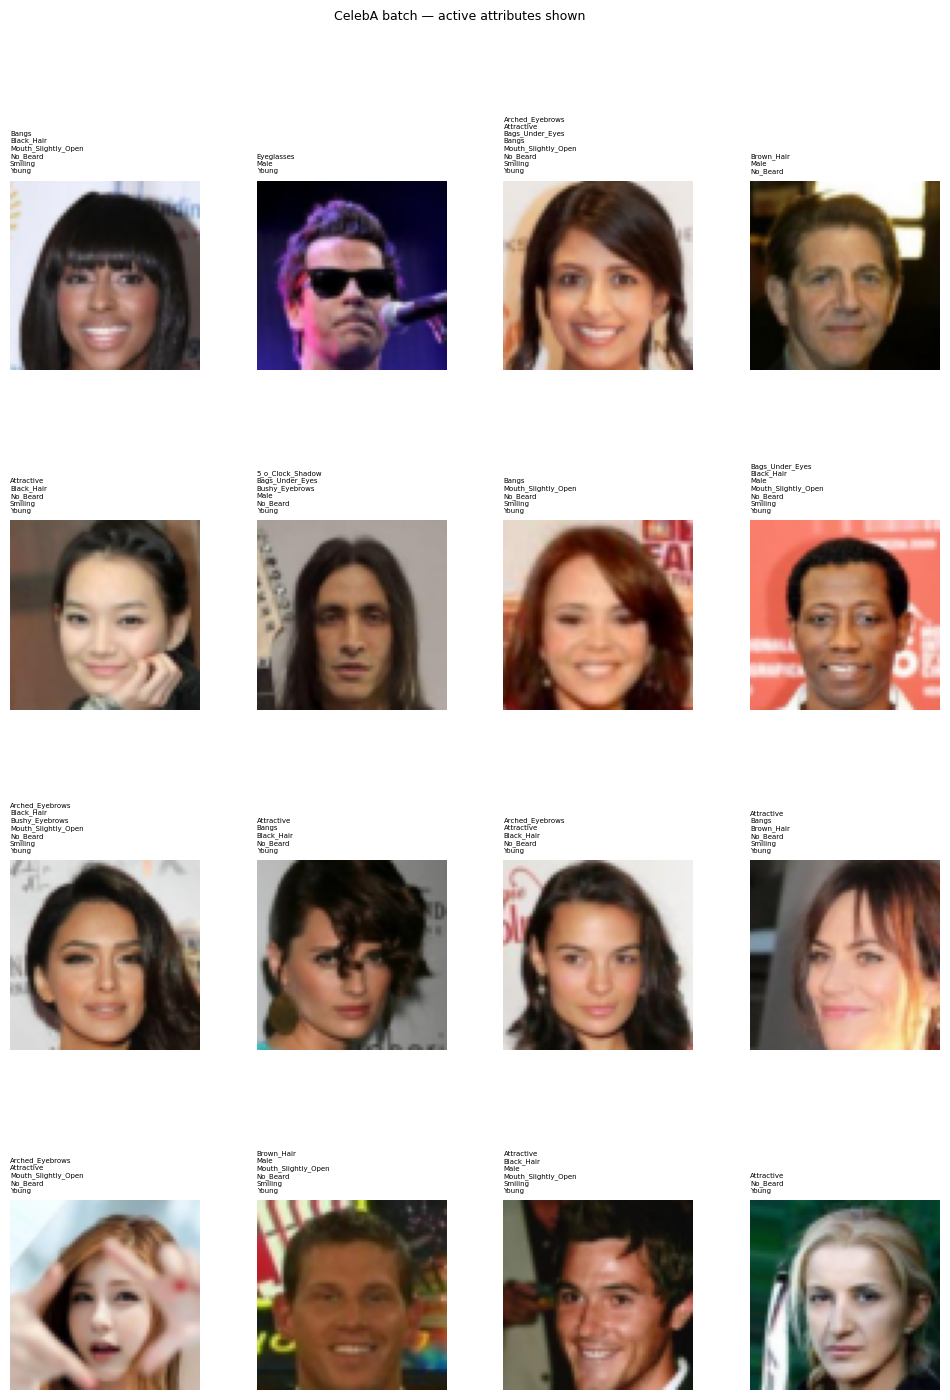

Saved grid to /content/drive/MyDrive/FaceForge/phase0_batch_grid.png


In [21]:
from data_pipeline import visualize_batch

grid_save_path = os.path.join(DRIVE_ROOT, 'phase0_batch_grid.png')

visualize_batch(images, attrs, n_rows=4, n_cols=4)

# Also save to Drive for reference
visualize_batch(images, attrs, n_rows=4, n_cols=4, save_path=grid_save_path)

## Attribute Statistics

Computes the mean (prevalence) and std of each attribute across all 162,770 training images.
Useful for understanding class imbalance before training.

In [24]:
from data_pipeline import compute_attr_statistics, print_attr_statistics
import torch

# Use a stats-only loader: no shuffle, larger batch for speed
stats_loader = make_dataloader(
    root=DATA_ROOT, split='train', download=False,
    batch_size=256, num_workers=4
)

stats = compute_attr_statistics(stats_loader)
print_attr_statistics(stats)

# Save stats to Drive
stats_path = os.path.join(DRIVE_ROOT, 'phase0_attr_stats.pt')
torch.save(stats, stats_path)
print(f'\nStats saved to {stats_path}')

Computing attribute statistics (this may take a minute)...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



Attribute statistics over 162,560 samples:

Attribute                     Mean      Std
---------------------------------------------
5_o_Clock_Shadow            0.1117   0.3150
Arched_Eyebrows             0.2658   0.4418
Attractive                  0.5136   0.4998
Bags_Under_Eyes             0.2045   0.4033
Bald                        0.0228   0.1493
Bangs                       0.1516   0.3587
Black_Hair                  0.2390   0.4265
Blond_Hair                  0.1491   0.3562
Brown_Hair                  0.2039   0.4029
Bushy_Eyebrows              0.1437   0.3508
Eyeglasses                  0.0646   0.2459
Male                        0.4194   0.4935
Mouth_Slightly_Open         0.4822   0.4997
Mustache                    0.0408   0.1978
No_Beard                    0.8342   0.3719
Pale_Skin                   0.0430   0.2029
Smiling                     0.4797   0.4996
Young                       0.7789   0.4150

Stats saved to /content/drive/MyDrive/FaceForge/phase0_attr_stats.pt


## Validation

In [25]:
import torch
from data_pipeline import make_dataloader, NUM_ATTRS

# Check 1: DataLoader iterates 3 batches without error
loader = make_dataloader(root=DATA_ROOT, split='train',
                         download=False, batch_size=64, num_workers=2)
for i, (imgs, atts) in enumerate(loader):
    if i == 2:
        break
print('DataLoader iterated 3 batches without error')

# Check 2: Image shape and range
assert imgs.shape[1:] == (3, 64, 64)
assert imgs.min() >= -1.01 and imgs.max() <= 1.01
print(f'Image shape {imgs.shape}, range [{imgs.min():.2f}, {imgs.max():.2f}]')

# Check 3: Attribute shape and dtype
assert atts.shape[1] == NUM_ATTRS and atts.dtype == torch.float32
print(f'Attribute shape {atts.shape}, dtype {atts.dtype}')

# Check 4: Stats file exists
stats_path = os.path.join(DRIVE_ROOT, 'phase0_attr_stats.pt')
assert os.path.exists(stats_path), f'Stats not found at {stats_path}'
print(f'Attribute stats saved at {stats_path}')

# Check 5: Grid image exists
grid_path = os.path.join(DRIVE_ROOT, 'phase0_batch_grid.png')
assert os.path.exists(grid_path), f'Grid image not found at {grid_path}'
print(f'Batch grid saved at {grid_path}')

DataLoader iterated 3 batches without error
Image shape torch.Size([64, 3, 64, 64]), range [-1.00, 1.00]
Attribute shape torch.Size([64, 18]), dtype torch.float32
Attribute stats saved at /content/drive/MyDrive/FaceForge/phase0_attr_stats.pt
Batch grid saved at /content/drive/MyDrive/FaceForge/phase0_batch_grid.png


---
# FaceForge — Phase 1: Baseline cVAE (Attribute Conditioning)

**Goal:** Train a Conditional VAE conditioned on 18 binary attributes for 30 epochs.

| Component | Details |
|---|---|
| AttrEmbedding | Linear(18→64)→ReLU→Linear(64→64)→ReLU |
| Encoder | 4× Conv2d (BN+LeakyReLU) → flatten → concat(attr_emb) → Linear(512) → μ, logvar [128] |
| Decoder | concat(z[128], attr_emb[64]) → Linear → 4× ConvTranspose2d → Tanh |
| Loss | MSE recon + β·KL, β=1.0 (reduce to 0.5 if posterior collapse) |
| Optimizer | Adam lr=2e-4, betas=(0.5, 0.999) |

In [ ]:
import torch
from baseline_cvae import BaselineCVAE, save_checkpoint, load_checkpoint

# ── Config ──────────────────────────────────────────────────────────────────
NUM_EPOCHS = 30
BATCH_SIZE = 64
LR         = 2e-4
BETA       = 1.0          # KL weight; reduce to 0.5 if outputs stay blurry
NUM_WORKERS = 2

CKPT_PATH  = os.path.join(CKPT_ROOT, 'baseline_cvae_latest.pt')
BEST_PATH  = os.path.join(CKPT_ROOT, 'baseline_cvae_best.pt')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Training on: {device}')

# ── Model + optimiser ───────────────────────────────────────────────────────
model     = BaselineCVAE(beta=BETA).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, betas=(0.5, 0.999))

# ── Resume if checkpoint exists ─────────────────────────────────────────────
start_epoch = 0
history     = {'total': [], 'recon': [], 'kl': []}

if os.path.exists(CKPT_PATH):
    start_epoch, history = load_checkpoint(CKPT_PATH, model, optimizer, device)
    print(f'Resumed from epoch {start_epoch}  '
          f'(best total loss so far: {min(history["total"]):.4f})')
else:
    print('No checkpoint found — training from scratch.')

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

In [ ]:
from data_pipeline import make_dataloader
from baseline_cvae import train_one_epoch

train_loader = make_dataloader(
    root=DATA_ROOT, split='train', download=False,
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True
)

best_loss = min(history['total']) if history['total'] else float('inf')

for epoch in range(start_epoch, NUM_EPOCHS):
    metrics = train_one_epoch(model, train_loader, optimizer, device)

    for k in history:
        history[k].append(metrics[k])

    is_best = metrics['total'] < best_loss
    if is_best:
        best_loss = metrics['total']
        save_checkpoint(model, optimizer, epoch + 1, history, BEST_PATH)

    save_checkpoint(model, optimizer, epoch + 1, history, CKPT_PATH)

    print(f'Epoch [{epoch+1:02d}/{NUM_EPOCHS}]  '
          f'total={metrics["total"]:.4f}  '
          f'recon={metrics["recon"]:.4f}  '
          f'kl={metrics["kl"]:.4f}'
          + ('  ← best' if is_best else ''))

print('\nTraining complete.')

## Loss Curves

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
labels = ['total', 'recon', 'kl']
titles = ['Total Loss', 'Reconstruction Loss (MSE)', 'KL Loss']

for ax, key, title in zip(axes, labels, titles):
    ax.plot(range(1, len(history[key]) + 1), history[key], marker='o', markersize=3)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
loss_curve_path = os.path.join(DRIVE_ROOT, 'phase1_loss_curves.png')
plt.savefig(loss_curve_path, dpi=120, bbox_inches='tight')
print(f'Saved to {loss_curve_path}')
plt.show()

## Reconstruction Visualisation

Feed real images through the cVAE (encode → reparameterise → decode) and compare side-by-side.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from data_pipeline import denormalize

N_SHOW = 8   # number of image pairs to display

model.eval()
val_loader = make_dataloader(
    root=DATA_ROOT, split='valid', download=False,
    batch_size=N_SHOW, num_workers=NUM_WORKERS, pin_memory=True
)
real_imgs, real_attrs = next(iter(val_loader))
real_imgs  = real_imgs.to(device)
real_attrs = real_attrs.to(device)

with torch.no_grad():
    recon_imgs, _, _ = model(real_imgs, real_attrs)

fig, axes = plt.subplots(2, N_SHOW, figsize=(N_SHOW * 2, 5))
fig.suptitle('Top: real    Bottom: reconstruction', fontsize=10)

for i in range(N_SHOW):
    axes[0, i].imshow(denormalize(real_imgs[i].cpu()))
    axes[0, i].axis('off')
    axes[1, i].imshow(denormalize(recon_imgs[i].cpu()))
    axes[1, i].axis('off')

plt.tight_layout()
recon_path = os.path.join(DRIVE_ROOT, 'phase1_reconstructions.png')
plt.savefig(recon_path, dpi=120, bbox_inches='tight')
print(f'Saved to {recon_path}')
plt.show()

## Phase 1 Validation

In [ ]:
import os
import torch
from baseline_cvae import BaselineCVAE, LATENT_DIM

print('── Phase 1 Validation ──────────────────────────────────────')

# 1. Checkpoint files exist
assert os.path.exists(CKPT_PATH), f'Latest checkpoint missing: {CKPT_PATH}'
assert os.path.exists(BEST_PATH), f'Best checkpoint missing: {BEST_PATH}'
print(f'[OK] Checkpoints saved: {CKPT_PATH}')

# 2. Training ran for expected epochs
assert len(history['total']) == NUM_EPOCHS, \
    f'Expected {NUM_EPOCHS} epoch entries, got {len(history["total"])}'
print(f'[OK] Trained for {NUM_EPOCHS} epochs')

# 3. Loss decreased overall (final < initial)
assert history['total'][-1] < history['total'][0], \
    f'Loss did not decrease: start={history["total"][0]:.4f}  end={history["total"][-1]:.4f}'
print(f'[OK] Total loss decreased: {history["total"][0]:.4f} → {history["total"][-1]:.4f}')

# 4. KL is non-zero (no posterior collapse)
assert history['kl'][-1] > 1e-3, \
    f'KL collapsed to ~0 ({history["kl"][-1]:.6f}). Consider reducing beta.'
print(f'[OK] KL term healthy: {history["kl"][-1]:.4f}')

# 5. Forward pass produces correct output shapes
model.eval()
dummy_imgs  = torch.zeros(4, 3, 64, 64, device=device)
dummy_attrs = torch.zeros(4, 18, device=device)
with torch.no_grad():
    recon, mu, logvar = model(dummy_imgs, dummy_attrs)
assert recon.shape  == (4, 3, 64, 64), f'Bad recon shape: {recon.shape}'
assert mu.shape     == (4, LATENT_DIM), f'Bad mu shape: {mu.shape}'
assert logvar.shape == (4, LATENT_DIM), f'Bad logvar shape: {logvar.shape}'
assert recon.min() >= -1.01 and recon.max() <= 1.01, 'Recon output outside [-1,1]'
print(f'[OK] Forward pass shapes: recon={tuple(recon.shape)}  mu={tuple(mu.shape)}')

# 6. Visualisation files saved to Drive
assert os.path.exists(os.path.join(DRIVE_ROOT, 'phase1_loss_curves.png'))
assert os.path.exists(os.path.join(DRIVE_ROOT, 'phase1_reconstructions.png'))
print('[OK] Visualisation files saved to Drive')

print('\nPhase 1 complete. Ready for human review before Phase 2.')